# Regression Using Tensorflow and Deep Learning

- Input layer shape
- Hidden layer(s)
- Neurons per hidden..layer
- Output layer shape
- Hidden activation
- output activation
- loss function
- optimizer

In [69]:
import tensorflow as tf
print(tf.__version__)

2.20.0


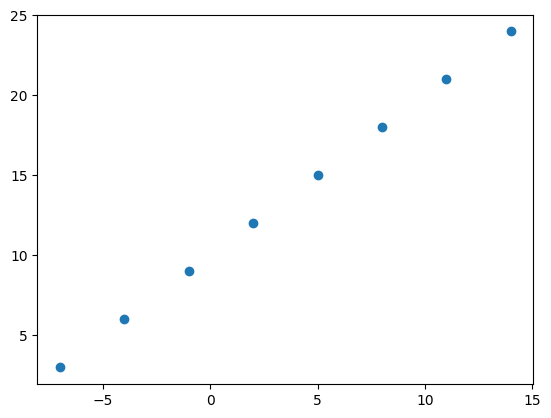

In [104]:
import numpy as np
import matplotlib.pyplot as plt

X = tf.constant(np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0]))
y = tf.constant(np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0]))

plt.scatter(X, y)

In [71]:
input_shape = X[0].shape
output_shape = y[0].shape
input_shape, output_shape # Output is ((), ()) because the dimention is 0, scalar tensors

(TensorShape([]), TensorShape([]))

## Steps in modeling with tensorflow


In [72]:
tf.random.set_seed(42)


# 1. Create a model using the sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. compile the model
model.compile(loss=tf.keras.losses.mae, optimizer=tf.keras.optimizers.SGD(), metrics=['mae'])

# Reshape X to be compatible with the Dense layer (add an extra dimension)
X_reshaped = tf.expand_dims(X, axis=-1)

# 3. Fit the model
model.fit(X_reshaped, y, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step - loss: 15.7142 - mae: 15.7142
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 15.4330 - mae: 15.4330
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 15.1517 - mae: 15.1517
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 14.9024 - mae: 14.9024
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 14.7699 - mae: 14.7699


In [73]:
# Making prediction
model.predict(tf.expand_dims(tf.constant([17.0]), axis=-1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


array([[-5.688386]], dtype=float32)

# Improving the model

we can improve our model, by altering the steps we took to create a model.
1. **Creating a model** - add more layers, increase the number of hidden units (all called neurons) within each of the hidden layers, change activation functions of each layer
2. **Compiling a model**: here we might change the opimization function or perhaps the learning rate
3. **Fitting a model**: increase the number of epochs


### Improvement 1

In [105]:
# 1. Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
], name="Model_1")

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=['mae'])

# 3. Fit the model
model.fit(X_reshaped, y, epochs=100, verbose=0) # what does verbose does, different modes

In [106]:
model.predict(tf.expand_dims(tf.constant([17.0]), axis=-1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


array([[29.264181]], dtype=float32)

### Improvement 2


What does each Dense mean, tf.keras.layers.Dense mean, and its parameters mean

In [107]:
# Create Model
model1 = tf.keras.Sequential([
    tf.keras.layers.Dense(50, activation=None, input_shape=[1], name='input_layer'), # Correct input_shape to match X's features
    # tf.keras.layers.Dense(100, activation='relu'),
    # tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(1, input_shape=[1], name='output_layer') # Removed redundant input_shape from subsequent Dense layer
], name='model_2') # 'model_2' is a valid name, the issue was likely with a historical prefix

# Compile the model
model1.compile(loss=tf.keras.losses.mae,
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
               metrics=['mae'])

In [108]:
model1.summary()

Model: "model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

- What are total params? - total number of parameters in the model
- Trainable params: the parameters that the model can update
- non-tranable params: freeze model data like in the, this parameters are not updated during training. transfer learning

MIT intro to Deep Learning


In [109]:
model1.fit(X, y, epochs=100, verbose=0)

In [110]:
data = tf.expand_dims([17.0], axis=-1)
model1.predict(data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


array([[29.264181]], dtype=float32)

The matrices that we are seeing while training might not be representative of the actual learning of the model

If add more neurons (layers) or epoches don't improve our model what does? how to know better what does and what does not?

Learning rate is the most imporatnt

More about adjusting Hyperparameters


## Evaluating a Models predictions

In [111]:
X = tf.range(-100, 100, 4)
y = X + 10

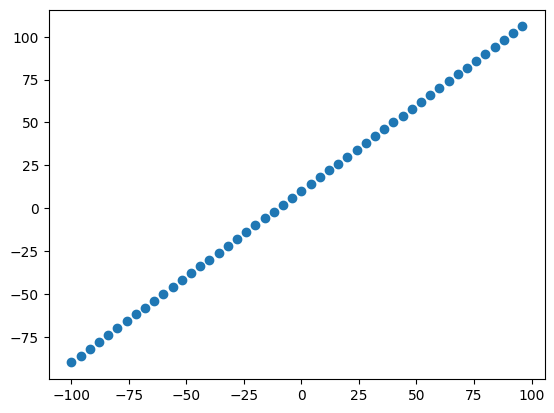

In [112]:
plt.scatter(X, y)

## The 3 Sets
- Training Set
- Validation Set
- Test Set

In [113]:
len(X)


X_train = X[:40]
y_train = y[:40]

X_test = X[40:]
y_test = y[40:]

X_train, y_train, X_test, y_test

(<tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
         -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
         -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
          32,   36,   40,   44,   48,   52,   56], dtype=int32)>,
 <tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
        -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
         14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
         66], dtype=int32)>,
 <tf.Tensor: shape=(10,), dtype=int32, numpy=array([60, 64, 68, 72, 76, 80, 84, 88, 92, 96], dtype=int32)>,
 <tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>)

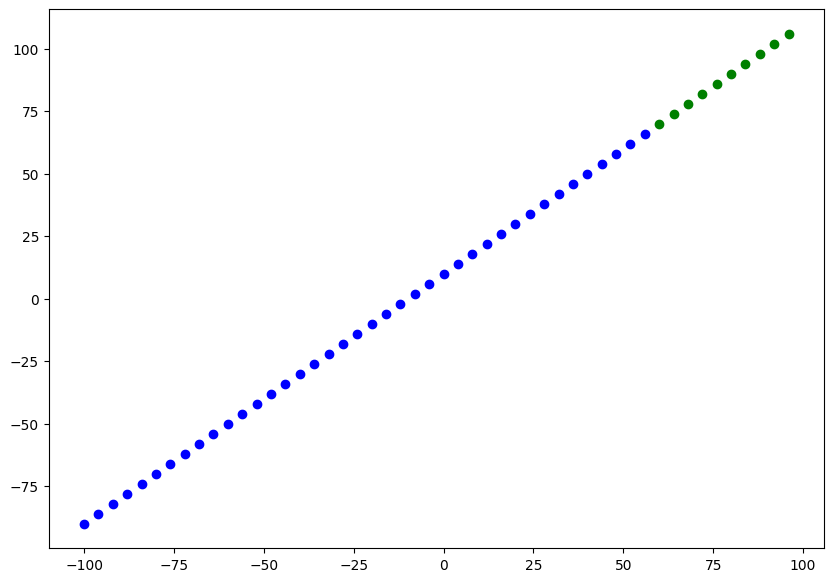

In [114]:
plt.figure(figsize=(10, 7))
plt.scatter(X_train, y_train, c='blue', label="Training Data")
plt.scatter(X_test, y_test, c='green', label="Testing Data")

In [129]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, input_shape=[1], name='layer_1'),
    tf.keras.layers.Dense(1, name='layer_2')
])

model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=['mae'])

model.fit(X_train, y_train, epochs=100, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Create a model which builds automatically by defining the input_shape argument in the first layer, how to define the input shape?

what does the verbose, fit argument does

In [130]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer_1 (Dense)                 │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303 (1.19 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

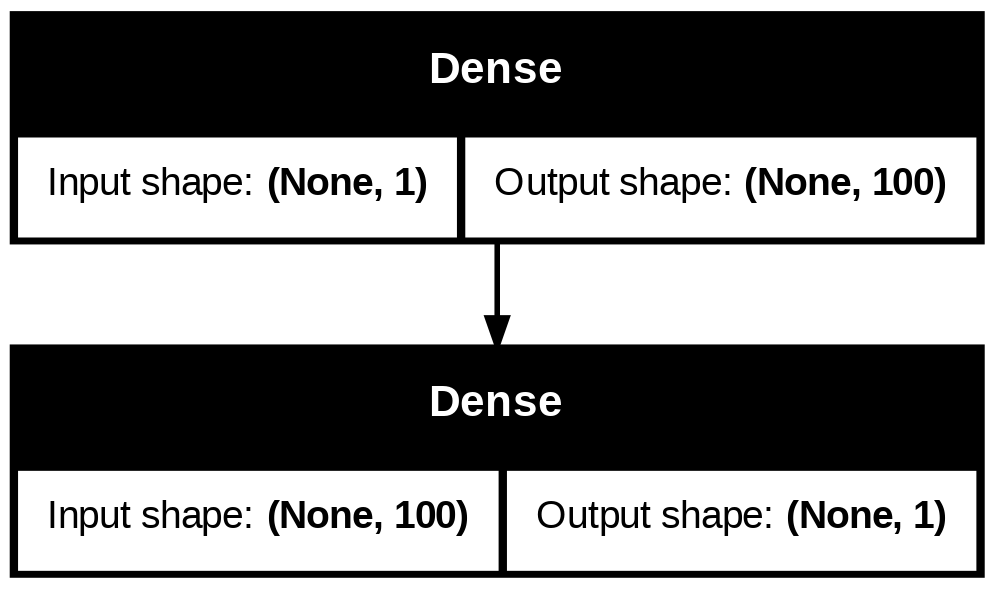

In [131]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True)

### Visualizing Model Predictions

- `y_true` vs `y_pred`

In [132]:
y_pred = model.predict(X_test)
y_pred, y_test

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


(array([[46.34415 ],
        [49.32187 ],
        [52.299583],
        [55.2773  ],
        [58.255016],
        [61.232727],
        [64.21044 ],
        [67.188156],
        [70.16587 ],
        [73.143585]], dtype=float32),
 <tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>)

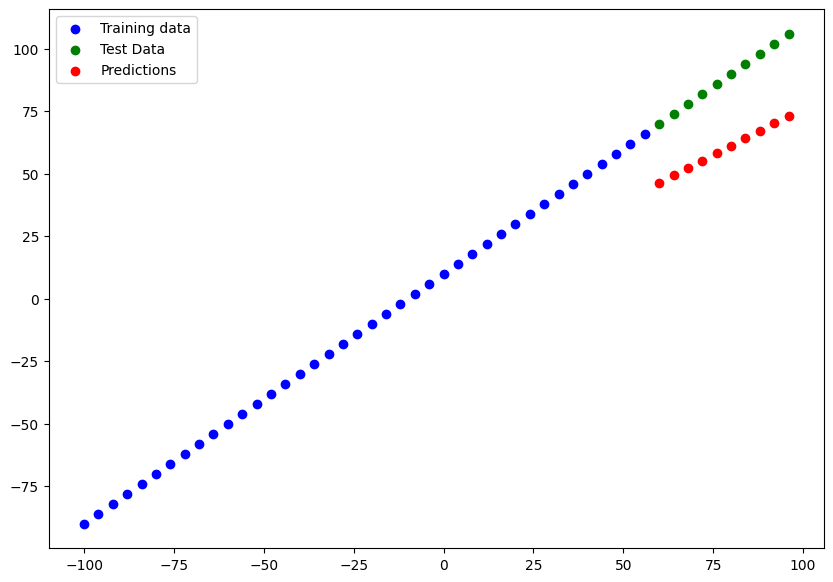

In [133]:
# Plotting Function
def plot_predictions(train_data =X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=y_pred):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))
  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="blue", label="Training data")
  # Plot test data in green
  plt.scatter(test_data, test_labels, c='green', label='Test Data')
  # Plot the predictions in red (predictions were made on the test data)
  plt.scatter(test_data, predictions, c='red', label='Predictions')
  # Show the legend
  plt.legend()
  plt.show()

plot_predictions()


## Practice


In [97]:
from sklearn.datasets import fetch_california_housing
data_frame = fetch_california_housing(as_frame=True)
df = data_frame.frame
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [96]:
X1 = tf.constant(df.drop('MedHouseVal', axis=1).values)
y1 = tf.constant(df['MedHouseVal'].values)

X1, y1

(<tf.Tensor: shape=(20640, 8), dtype=float64, numpy=
 array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]])>,
 <tf.Tensor: shape=(20640,), dtype=float64, numpy=array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])>)